# Identify Yourself 

In [2]:
# --- Cell 1: identify yourself ---

name = "Riodino Laihan"
student_id = "50261893"

print(name, student_id)

Riodino Laihan 50261893


# Q1 Load the Data 

In [3]:
import pandas as pd

stock_url = "https://raw.githubusercontent.com/riodino14/colab-project/main/stockReturnDF2.csv"
shares_url = "https://raw.githubusercontent.com/riodino14/colab-project/main/ShareOutstanding.csv"

stockDF = pd.read_csv(stock_url)
shareOutDF = pd.read_csv(shares_url)

print("Stock DataFrame shape:", stockDF.shape)
print("Share Outstanding DataFrame shape:", shareOutDF.shape)

Stock DataFrame shape: (15099, 10)
Share Outstanding DataFrame shape: (3, 2)


In [4]:
# # --- Q1: Load the data ---

# import pandas as pd

# stockDF = pd.read_csv("stockReturnDF2.csv")
# shareOutDF = pd.read_csv("ShareOutstanding.csv")

# print("Stock DataFrame shape:", stockDF.shape)
# print("Share Outstanding DataFrame shape:", shareOutDF.shape)

# Q2. Look at the Data

The price data contains daily stock price information for each ticker.

In [5]:
# Show the first 5 rows 
stockDF.head()

,date,open,high,low,close,adjusted close,volume,dividend amount,split coefficient,ticker
0,2019-10-31,168.51,168.56,163.55,164.99,164.99,2639274,0.0,1.0,MMM
1,2019-10-30,168.23,168.57,167.03,168.37,168.37,1780100,0.0,1.0,MMM
2,2019-10-29,168.03,169.95,167.51,168.81,168.81,2669200,0.0,1.0,MMM
3,2019-10-28,166.48,169.71,166.20,169.06,169.06,3137500,0.0,1.0,MMM
4,2019-10-25,162.51,167.63,162.13,166.09,166.09,3104700,0.0,1.0,MMM


In [6]:
# Show the last 5 Rows 
stockDF.tail()

,date,open,high,low,close,adjusted close,volume,dividend amount,split coefficient,ticker
15094,1999-11-05,37.875,38.875,37.8750,38.438,10.6687,13604600,0.0,1.0,ABT
15095,1999-11-04,37.438,38.250,37.0000,37.875,10.5125,15124600,0.0,1.0,ABT
15096,1999-11-03,37.750,38.250,36.8130,36.813,10.2176,19538700,0.0,1.0,ABT
15097,1999-11-02,39.063,39.625,37.5615,38.000,10.5472,22183400,0.0,1.0,ABT
15098,1999-11-01,40.500,41.125,40.0000,40.313,11.1891,8656500,0.0,1.0,ABT


One row represents the daily stock price and trading information for one ticker on one trading day.

# Q3. Columns 

In [7]:
# Print the column names 
print("Column names: ")
print(stockDF.columns.tolist())
print("number of columns: ",len(stockDF.columns.tolist()))

# Count the unique tickers 
print("List of the unique tickers: ", stockDF["ticker"].unique())
print("Total number of the unique tickers ", len(stockDF["ticker"].unique()))
# print(stockDF["ticker"].nunique()) 

Column names: 
['date', 'open', 'high', 'low', 'close', 'adjusted close', 'volume', 'dividend amount', 'split coefficient', 'ticker']
number of columns:  10
List of the unique tickers:  ['MMM' 'AOS' 'ABT']
Total number of the unique tickers  3


# Q4. Add a Column 
Add Dollar Volume. 
Dollar volume is calculated as:

dollarVolume = close × volume

In [8]:
stockDF["dollarVolume"] = stockDF["close"] * stockDF["volume"]

# show the first 5 rows 
stockDF["volume"].head()

,volume
0,2639274
1,1780100
2,2669200
3,3137500
4,3104700


# Q5. Merge 
The two DataFrames are merged using `ticker` as the key.

In [9]:
# shape before merging 
shape_before = stockDF.shape

# merge using ticker 
merged = stockDF.merge(shareOutDF,on="ticker",how="inner" )

print("Shape before merging: ", shape_before)
print("shape after merging: ", merged.shape)

# checked wether any rows were lost 
if merged.shape[0] == shape_before[0]: 
    print("No rows were lost.")
else: 
    print("Some rows were lost.")


Shape before merging:  (15099, 11)
shape after merging:  (15099, 12)
No rows were lost.


# Q.6. Market Cap 

Market capitalization is calculated as:

marketCap = adjusted close × sharesOutstanding

In [10]:
merged.head()

,date,open,high,low,close,adjusted close,volume,dividend amount,split coefficient,ticker,dollarVolume,sharesOutstanding
0,2019-10-31,168.51,168.56,163.55,164.99,164.99,2639274,0.0,1.0,MMM,4.354538e+08,576019008
1,2019-10-30,168.23,168.57,167.03,168.37,168.37,1780100,0.0,1.0,MMM,2.997154e+08,576019008
2,2019-10-29,168.03,169.95,167.51,168.81,168.81,2669200,0.0,1.0,MMM,4.505877e+08,576019008
3,2019-10-28,166.48,169.71,166.20,169.06,169.06,3137500,0.0,1.0,MMM,5.304258e+08,576019008
4,2019-10-25,162.51,167.63,162.13,166.09,166.09,3104700,0.0,1.0,MMM,5.156596e+08,576019008


In [11]:
# Calculate market capitalization
merged["marketCap"] = merged["adjusted close"] * merged["sharesOutstanding"]
# Show the first 5 rows 
merged.head()


,date,open,high,low,close,adjusted close,volume,dividend amount,split coefficient,ticker,dollarVolume,sharesOutstanding,marketCap
0,2019-10-31,168.51,168.56,163.55,164.99,164.99,2639274,0.0,1.0,MMM,4.354538e+08,576019008,9.503738e+10
1,2019-10-30,168.23,168.57,167.03,168.37,168.37,1780100,0.0,1.0,MMM,2.997154e+08,576019008,9.698432e+10
2,2019-10-29,168.03,169.95,167.51,168.81,168.81,2669200,0.0,1.0,MMM,4.505877e+08,576019008,9.723777e+10
3,2019-10-28,166.48,169.71,166.20,169.06,169.06,3137500,0.0,1.0,MMM,5.304258e+08,576019008,9.738177e+10
4,2019-10-25,162.51,167.63,162.13,166.09,166.09,3104700,0.0,1.0,MMM,5.156596e+08,576019008,9.567100e+10


# Q7. Plot Market Cap  

In [12]:
merged["ticker"].unique()

array(['MMM', 'AOS', 'ABT'], dtype=object)

The ticker selected for the plot is MMM.

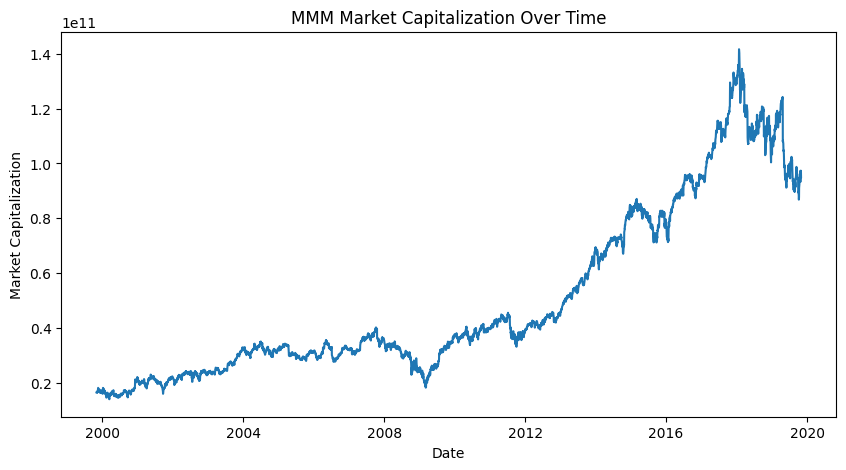

In [13]:
import matplotlib.pyplot as plt

# Filter the data for MMM
mmmDF = merged[merged["ticker"] == "MMM"].copy()

# Convert date to datetime
mmmDF["date"] = pd.to_datetime(mmmDF["date"])

# Sort by date
mmmDF = mmmDF.sort_values("date")

# Plot market capitalization over time
plt.figure(figsize=(10, 5))
plt.plot(mmmDF["date"], mmmDF["marketCap"])

plt.xlabel("Date")
plt.ylabel("Market Capitalization")
plt.title("MMM Market Capitalization Over Time")

plt.show()

In [14]:
B = [1, 2, 3] # B adalah data kompleks (list)
A = B         # A hanya mendapat "kunci serep" ke rumah B, BUKAN copy-an!

A[0] = 99     # Kita mengubah isi A

print(B)      
# Hasilnya: [99, 2, 3] -> Lho? B ikut berubah!

[99, 2, 3]


## Q8. Save the Merged DataFrame

The merged DataFrame is saved as `merged_50261893.csv`.

In [15]:
# Save the merged DataFrame
merged.to_csv("merged_50261893.csv", index=False)

# Check that the file exists
!ls

merged_50261893.csv  sample_data


# Q9. Exploratory Data Analysis

To answer the final question, we first identify the most recent date in the dataset and compare the market capitalization of the three companies on that date.

In [16]:
# Find the most recent date
merged["date"] = pd.to_datetime(merged["date"])

latest_date = merged["date"].max()

print("Most recent date:", latest_date)

Most recent date: 2019-10-31 00:00:00


In [17]:
# Filter the data for the most recent date
latest_data = merged[merged["date"] == latest_date].copy()

# Display market capitalization for each ticker
latest_market_cap = latest_data[
    ["ticker", "marketCap"]
].sort_values("marketCap", ascending=False)

latest_market_cap

,ticker,marketCap
10066,ABT,1.480340e+11
0,MMM,9.503738e+10
5033,AOS,6.725430e+09


In [18]:
# Identify the largest and smallest companies by market cap
largest = latest_market_cap.iloc[0]
smallest = latest_market_cap.iloc[-1]

print("Largest company:", largest["ticker"])
print("Largest market cap:", largest["marketCap"])

print("Smallest company:", smallest["ticker"])
print("Smallest market cap:", smallest["marketCap"])

Largest company: ABT
Largest market cap: 148034017313.28
Smallest company: AOS
Smallest market cap: 6725430397.44


In [19]:
# Calculate how many times larger the largest market cap is than the smallest
ratio = largest["marketCap"] / smallest["marketCap"]

print("Ratio:", ratio)
print(
    f'{largest["ticker"]} is approximately '
    f'{ratio:.1f} times larger than {smallest["ticker"]}.'
)

Ratio: 22.011084579750968
ABT is approximately 22.0 times larger than AOS.


## Q9. Final Answer

On the most recent date in the data, ABT had the largest market capitalization, while AOS had the smallest. ABT's market capitalization was approximately 22 times larger than AOS's.